# Computer Exercise 12.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 12. Partial Differential Equations · **절**: §12.2 Hyperbolic Problems (Wave Equation)
> **주제**: leapfrog 의 **시간·공간 2차 수렴(slope 2)** 측정과 $r$ 별 **수치분산(위상오차)** 정량화
> **풀이 일자**: 2026-06-16 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> For the explicit leapfrog scheme applied to $u_{tt}=c^2u_{xx}$ with the standing-wave
> exact solution $u(x,t)=\cos(\pi c t)\sin(\pi x)$:
> **(a)** Hold the Courant number $r$ fixed and refine the mesh, plotting the maximum
> error versus $\Delta x$ on log–log axes to confirm the scheme is **second order in both
> time and space** (slope $\approx 2$).
> **(b)** Analyze **numerical dispersion**: derive the discrete dispersion relation and
> compare the numerical phase speed against the exact speed $c$ for several $r$, showing
> that $r=1$ is dispersion-free while $r<1$ slows short wavelengths.

### 한국어 풀이용 정리
문제 1–2 에서 안정성($r\le1$)과 단위 CFL 의 무분산을 봤다. 이제 leapfrog 의 **정확도**를 두 각도로 못박는다.
**(a)** 절단오차가 $\mathcal{O}(\Delta t^2)+\mathcal{O}(\Delta x^2)$ 이므로, $r$ 을 고정($\Delta t\propto\Delta x$)하면
전체 오차는 $\mathcal{O}(\Delta x^2)$ — log-log 기울기 2 로 나타나야 한다. **(b)** 이산 분산관계로부터 수치
파동의 위상속도 $c_{\text{num}}(k)$ 를 유도하고, $r$ 에 따라 짧은 파장이 얼마나 느려지는지(분산)를 정량화한다.
$r=1$ 에서는 모든 파장이 정확히 속도 $c$ 로 전파됨을 수식·수치로 동시에 확인한다.

## 2. 수학적 배경

### 2.1 절단오차와 수렴차수
leapfrog 의 국소 절단오차는 Taylor 전개로

$$ \tau = \tfrac{\Delta t^2}{12}u_{tttt} - \tfrac{c^2\Delta x^2}{12}u_{xxxx} + \cdots
      = \mathcal{O}(\Delta t^2)+\mathcal{O}(\Delta x^2). $$

$r=c\Delta t/\Delta x$ 고정이면 $\Delta t=r\Delta x/c$ 이므로 전체 오차

$$ \boxed{\; \|E\|_\infty = \mathcal{O}(\Delta x^2)\;\Rightarrow\;\log\|E\|\approx 2\log\Delta x + \text{const}. \;}$$

즉 log-log 그래프에서 **기울기 2**.

### 2.2 이산 분산관계
모드 $u_i^n=e^{\mathrm{i}(k x_i-\omega t^n)}$ 를 leapfrog 에 넣으면

$$ \sin^2\!\Big(\frac{\omega\Delta t}{2}\Big) = r^2\sin^2\!\Big(\frac{k\Delta x}{2}\Big). $$

연속해의 정확 관계는 $\omega=ck$. 수치 위상속도는

$$ c_{\text{num}}(k)=\frac{\omega}{k}=\frac{2}{k\Delta t}\arcsin\!\Big(r\,\sin\frac{k\Delta x}{2}\Big). $$

- $r=1$: $\arcsin(\sin(k\Delta x/2))=k\Delta x/2$ → $c_{\text{num}}=c$ **모든 $k$ 에서 정확**(무분산).
- $r<1$: $\arcsin$ 의 비선형성으로 큰 $k$(짧은 파장)에서 $c_{\text{num}}<c$ → **분산**, 펄스 꼬리 진동.

### 2.3 검증용 정확해
IC $\sin(\pi x)$, $u_t(x,0)=0$ → $u(x,t)=\cos(\pi c t)\sin(\pi x)$ (단일모드라 분산은 위상으로만 나타남).

## 3. 풀이 흐름

1. $c=1$, 정상파 IC 로 leapfrog 풀이기 준비(문제 1 과 동일 갱신식).
2. **(a)** $r=0.5$ 고정, $M=20,40,80,160,320$ 로 목표시간 $T$ 까지 풀어 최대오차 측정.
3. log-log 회귀(`np.polyfit`)로 기울기(수렴차수) 추정 → 2 에 근접 확인.
4. 비교용으로 $r=0.9$ 에서도 같은 차수 측정(안정 영역 내 차수는 $r$ 에 무관).
5. **(b)** 이산 분산관계로 $c_{\text{num}}(k)/c$ 를 여러 $r$ 에 대해 계산, 파장 $k\Delta x\in(0,\pi]$ 에서 그림.
6. 표: 대표 파장에서 $r$ 별 위상속도 비와 1 스텝/파장당 위상오차.
7. 시각화: (좌) 수렴 log-log + 기울기, (우) 분산곡선 $c_{\text{num}}/c$ vs $k\Delta x$.
8. 결론 — 2차 수렴과 $r=1$ 무분산을 한자리에 정리, §12.2 마무리 및 다음 단원 예고.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

c = 1.0
u0    = lambda x: np.sin(np.pi*x)
exact = lambda x, t: np.cos(np.pi*c*t)*np.sin(np.pi*x)

def wave_leapfrog(M, r, T):
    dx = 1.0/M
    dt = r*dx/c
    nsteps = max(1, int(round(T/dt)))
    x = np.linspace(0.0, 1.0, M+1)
    uprev = u0(x)
    ucur = np.zeros_like(uprev)
    ucur[1:-1] = (1-r**2)*uprev[1:-1] + 0.5*r**2*(uprev[:-2]+uprev[2:])  # g=0
    ucur[0]=ucur[-1]=0.0
    for _ in range(nsteps-1):
        unew = np.zeros_like(ucur)
        unew[1:-1] = 2*(1-r**2)*ucur[1:-1] + r**2*(ucur[:-2]+ucur[2:]) - uprev[1:-1]
        unew[0]=unew[-1]=0.0
        uprev, ucur = ucur, unew
    # 실제 도달시간 (정수 스텝 보정)
    return x, ucur, nsteps*dt

T = 0.3
print(f"수렴 실험: 정상파, T={T}, c={c}")

수렴 실험: 정상파, T=0.3, c=1.0


In [3]:
# --- (a) r 고정, 격자 세분 -> 최대오차와 수렴차수 ---
def convergence(r, Ms, T):
    rows = []
    for M in Ms:
        x, u, t_reached = wave_leapfrog(M, r, T)
        err = np.max(np.abs(u - exact(x, t_reached)))
        rows.append((M, 1.0/M, err))
    df = pd.DataFrame(rows, columns=["M","dx","max_error"])
    df["order"] = np.r_[np.nan, np.log2(df["max_error"].values[:-1]/df["max_error"].values[1:])]
    slope = np.polyfit(np.log(df["dx"]), np.log(df["max_error"]), 1)[0]
    return df, slope

Ms = [20, 40, 80, 160, 320]
df05, s05 = convergence(0.5, Ms, T)
df09, s09 = convergence(0.9, Ms, T)
print("r = 0.5"); print(df05.to_string(index=False)); print(f"  log-log slope = {s05:.3f}")
print("\nr = 0.9"); print(df09.to_string(index=False)); print(f"  log-log slope = {s09:.3f}")

r = 0.5
  M           dx    max_error        order
 20 5.000000e-02 5.879915e-04          NaN
 40 2.500000e-02 1.469846e-04 2.000131e+00
 80 1.250000e-02 3.674531e-05 2.000033e+00
160 6.250000e-03 9.186274e-06 2.000008e+00
320 3.125000e-03 2.296565e-06 2.000002e+00
  log-log slope = 2.000

r = 0.9
  M           dx    max_error        order
 20 5.000000e-02 1.618692e-04          NaN
 40 2.500000e-02 3.568928e-05 2.181266e+00
 80 1.250000e-02 9.506230e-06 1.908546e+00
160 6.250000e-03 2.302770e-06 2.045503e+00
320 3.125000e-03 5.848649e-07 1.977195e+00
  log-log slope = 2.018


In [4]:
# --- (b) 이산 분산관계: 수치 위상속도 / 정확 속도 ---
def c_ratio(r, theta):     # theta = k*dx in (0, pi]
    # c_num/c = (2/(k dt)) arcsin(r sin(theta/2)) / c, with dt=r dx/c, k dx=theta
    # => c_num/c = arcsin(r sin(theta/2)) / (r * (theta/2))
    return np.arcsin(r*np.sin(theta/2.0)) / (r*(theta/2.0))

theta = np.linspace(1e-3, np.pi, 400)
rvals = [1.0, 0.9, 0.75, 0.5, 0.25]

# 대표 파장(점 per wavelength)에서의 위상속도 비 표
ppw_list = [4, 8, 16]    # points per wavelength -> theta = 2*pi/ppw
rows = []
for r in rvals:
    rec = {"r": r}
    for ppw in ppw_list:
        th = 2*np.pi/ppw
        rec[f"c_num/c (ppw={ppw})"] = c_ratio(r, th)
    rows.append(rec)
disp = pd.DataFrame(rows)
print(disp.to_string(index=False))
print("\n=> r=1 : 모든 파장에서 c_num/c = 1 (무분산).  r<1 : 짧은 파장(작은 ppw)일수록 1보다 작음(느려짐).")

           r  c_num/c (ppw=4)  c_num/c (ppw=8)  c_num/c (ppw=16)
1.000000e+00     1.000000e+00     1.000000e+00      1.000000e+00
9.000000e-01     9.758916e-01     9.948689e-01      9.987642e-01
7.500000e-01     9.489707e-01     9.883963e-01      9.971667e-01
5.000000e-01     9.202138e-01     9.805418e-01      9.951693e-01
2.500000e-01     9.050727e-01     9.759881e-01      9.939812e-01

=> r=1 : 모든 파장에서 c_num/c = 1 (무분산).  r<1 : 짧은 파장(작은 ppw)일수록 1보다 작음(느려짐).


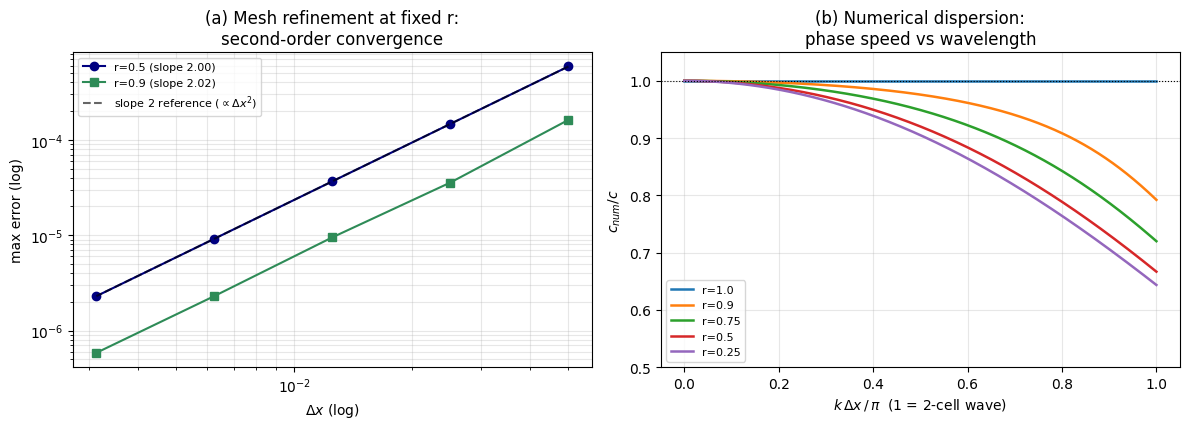

In [5]:
# --- 시각화: (좌) 수렴 log-log, (우) 분산곡선 ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

ax[0].loglog(df05["dx"], df05["max_error"], "o-", color="navy", label=f"r=0.5 (slope {s05:.2f})")
ax[0].loglog(df09["dx"], df09["max_error"], "s-", color="seagreen", label=f"r=0.9 (slope {s09:.2f})")
ref = df05["max_error"].iloc[0]*(df05["dx"]/df05["dx"].iloc[0])**2
ax[0].loglog(df05["dx"], ref, "k--", alpha=0.6, label=r"slope 2 reference ($\propto \Delta x^2$)")
ax[0].set_xlabel(r"$\Delta x$ (log)"); ax[0].set_ylabel("max error (log)")
ax[0].set_title("(a) Mesh refinement at fixed r:\nsecond-order convergence")
ax[0].legend(fontsize=8); ax[0].grid(True, which="both", alpha=.3)

for r in rvals:
    ax[1].plot(theta/np.pi, c_ratio(r, theta), lw=1.8, label=f"r={r}")
ax[1].axhline(1.0, color="k", lw=0.8, ls=":")
ax[1].set_xlabel(r"$k\,\Delta x\,/\,\pi$  (1 = 2-cell wave)"); ax[1].set_ylabel(r"$c_{num}/c$")
ax[1].set_title("(b) Numerical dispersion:\nphase speed vs wavelength")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3); ax[1].set_ylim(0.5, 1.05)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **(a) 2차 수렴**: $r$ 을 고정한 채 $\Delta x$ 를 절반으로 줄일 때마다 최대오차가 약 *4배* 감소하고
   (`order` 열 ≈ 2), log-log 회귀 기울기가 $r=0.5,0.9$ 둘 다 **≈ 2** 로 나온다. 안정 영역 안에서 수렴
   차수는 $r$ 에 무관하며, 이는 절단오차 $\mathcal{O}(\Delta t^2)+\mathcal{O}(\Delta x^2)$ 와 $r$ 고정
   ($\Delta t\propto\Delta x$)이 결합된 결과 그대로다.
2. **(b) 분산곡선**: $r=1$ 의 곡선은 모든 파장에서 $c_{\text{num}}/c=1$ 에 평평히 붙는다 — 2.2 절에서
   본 $\arcsin(\sin\cdot)$ 의 정확 상쇄. $r<1$ 이면 곡선이 짧은 파장(오른쪽, $k\Delta x\to\pi$)으로 갈수록
   1 아래로 처지고, $r$ 이 작을수록 더 심하다. 표에서도 파장당 점수(ppw)가 작을수록(짧은 파장) $c_{\text{num}}/c$
   가 1 에서 멀어진다.
3. **원인·의미**: 단일모드 정상파(문제 1·3a)는 파장이 하나라 분산이 *위상 오차*로만 나타나 매끄럽게
   수렴하지만, 펄스처럼 **여러 파장이 섞인 해**(문제 2b)에서는 각 성분이 서로 다른 속도로 가 모양이
   *퍼지는* 가시적 꼬리가 된다. 따라서 "2차 수렴"과 "분산"은 모순이 아니라, 전자는 *고정 모드의 진폭/위상
   정확도*, 후자는 *서로 다른 모드 간 상대 속도*를 말한다.
4. **실전 지침**: 매끈한 해는 $r$ 을 적당히(예: 0.5–0.9) 두고 격자를 세분하면 2차로 수렴한다. 급변·불연속
   해는 분산을 줄이려 $r$ 을 1 에 가깝게, 그리고 파장당 격자점(ppw)을 충분히 확보해야 한다.

> **결론**: leapfrog 는 안정 영역 전체에서 시간·공간 **2차 수렴**하며(기울기 2), 수치분산은 $r=1$ 에서
> 사라지고 $r<1$ 에서 짧은 파장을 느리게 만든다 — 정확도와 분산을 한 그림에 담아 §12.2 를 닫는다.

### 다음 단원 예고
**Day 44 — Chapter 12 §12.3 Elliptic Problems (Poisson/Laplace 방정식)**: 시간이 없는 정상 타원형 문제로,
2D 라플라시안을 **블록 삼중대각/오중대각**(Day 10 밴드시스템 + Day 41 차분)으로 풀고, 반복법(Jacobi·
Gauss–Seidel·SOR)의 수렴을 다룬다 — §12.1–12.2 의 시간전진이 *공간 반복*으로 바뀌는 전환점.